In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DATA_DIR = '/content/drive/MyDrive/NLP_Project_2.2/data'
it_path = f'{DATA_DIR}/europarl-v7.it-en.it'
en_path = f'{DATA_DIR}/europarl-v7.it-en.en'
glove_path = f'{DATA_DIR}/glove.6B.100d.txt'

print(os.path.exists(it_path), os.path.exists(en_path))
print(os.path.getsize(it_path) / 1e6, "MB")
print(os.path.getsize(en_path) / 1e6, "MB")

True True
325.578545 MB
298.376207 MB


In [ ]:
with open(glove_path, encoding='utf-8') as f:
    first_line = f.readline()
parts = first_line.rstrip().split(" ")
print("Word:", parts[0])
print("Vector size:", len(parts) - 1)

Word: the
Vector size: 100


## Task 1: Data exploration

In [ ]:
with open(it_path, encoding='utf-8') as f:
    it_lines = f.readlines()

with open(en_path, encoding='utf-8') as f:
    en_lines = f.readlines()

print("Number of Italian lines:", len(it_lines))
print("Number of English lines:", len(en_lines))
assert len(it_lines) == len(en_lines), "Line counts don't match!"

for i in range(3):
    print("EN:", en_lines[i].strip())
    print("IT:", it_lines[i].strip())
    print("---")

Number of Italian lines: 1909115
Number of English lines: 1909115
EN: Resumption of the session
IT: Ripresa della sessione
---
EN: I declare resumed the session of the European Parliament adjourned on Friday 17 December 1999, and I would like once again to wish you a happy new year in the hope that you enjoyed a pleasant festive period.
IT: Dichiaro ripresa la sessione del Parlamento europeo, interrotta venerdì 17 dicembre e rinnovo a tutti i miei migliori auguri nella speranza che abbiate trascorso delle buone vacanze.
---
EN: Although, as you will have seen, the dreaded 'millennium bug' failed to materialise, still the people in a number of countries suffered a series of natural disasters that truly were dreadful.
IT: Come avrete avuto modo di constatare il grande "baco del millennio" non si è materializzato. Invece, i cittadini di alcuni nostri paesi sono stati colpiti da catastrofi naturali di proporzioni davvero terribili.
---


In [ ]:
# strip empty lines and their correspondences and remove XML-tag lines
def is_valid_pair(en, it):
    en_stripped = en.strip()
    it_stripped = it.strip()
    if en_stripped == "" or it_stripped == "":
        return False
    if en_stripped.startswith("<") or it_stripped.startswith("<"):
        return False
    return True

pairs = [(en, it) for en, it in zip(en_lines, it_lines) if is_valid_pair(en, it)]
en_lines, it_lines = zip(*pairs)
print(f"kept {len(en_lines)} lines after removing empty lines and XML-tag lines")

kept 1900873 lines after removing empty lines and XML-tag lines


en percentiles: [ 24.  46.  54.  74. 668.]
it percentiles: [ 23.  44.  53.  72. 558.]
3104 sentences over 100 tokens
In my opinion, this second hypothesis would imply the failure of Parliament in its duty as a Parliament, as well as introducing an original thesis, an unknown method which consists of making political groups aware, in writing, of a speech concerning the Commission' s programme a week earlier - and n
Longest sentences length:  668


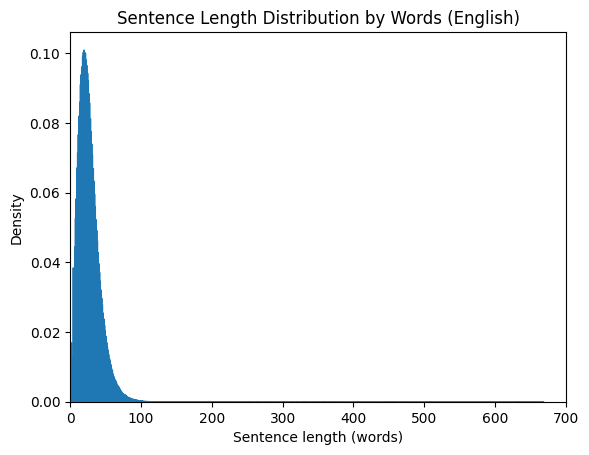

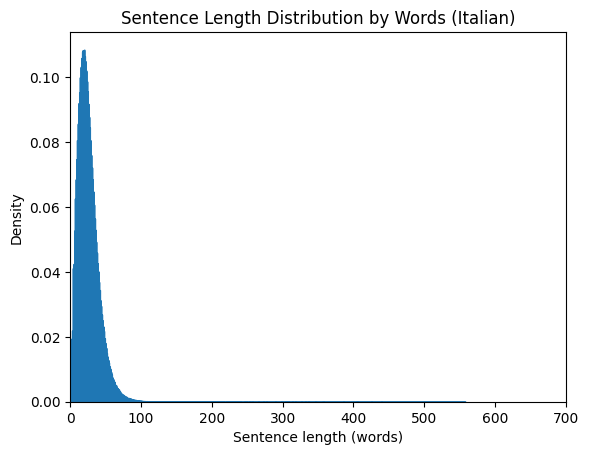

In [ ]:
# Sentence length distribution
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np


it_lens = list(map(lambda x: len(x.split()), it_lines))
en_lens = list(map(lambda x: len(x.split()), en_lines))


df_en = pd.DataFrame({
    "length":  en_lens,
    "language": ["English"] * len(en_lens)
})

df_it = pd.DataFrame({
    "length": it_lens,
    "language": ["Italian"] * len(it_lens)
})


print("en percentiles:", np.percentile(en_lens, [50, 90, 95, 99, 100]))
print("it percentiles:", np.percentile(it_lens, [50, 90, 95, 99, 100]))

# look at the actual long ones
long_idx = [i for i, l in enumerate(en_lens) if l > 100]
print(len(long_idx), "sentences over 100 tokens")
print(en_lines[long_idx[0]][:300])  # eyeball one
print("Longest sentences length: ", max(max(en_lens),max(it_lens)))

sns.histplot(data=df_en, x="length",  element="step", stat="density", common_norm=False)
plt.xlim(0, 700)
plt.xlabel("Sentence length (words)")
plt.title("Sentence Length Distribution by Words (English)")
plt.show()

sns.histplot(data=df_it, x="length", element="step", stat="density", common_norm=False)
plt.xlim(0, 700)
plt.xlabel("Sentence length (words)")
plt.title("Sentence Length Distribution by Words (Italian)")
plt.show()

#### Filter sentences over a certain length to prevent maxing out ram

In [ ]:
MAX_LEN = 80

pairs = [(en, it) for en, it in zip(en_lines, it_lines)
         if len(en.split()) <= MAX_LEN and len(it.split()) <= MAX_LEN]
en_lines, it_lines = zip(*pairs)
print(f"kept {len(en_lines)} lines after filtering disproportionally long ones")


kept 1886235 lines after filtering disproportionally long ones


In [ ]:
# Randomly select 10% of the data
import random
random.seed(123)
n_samples = int(len(it_lines)*0.1)
#it_sample = random.sample(it_lines, k=n_samples)
#en_sample = random.sample(en_lines, k=n_samples)

sampled_indices = random.sample(range(len(it_lines)), k=n_samples)

en_sample = [en_lines[i] for i in sampled_indices]
it_sample = [it_lines[i] for i in sampled_indices]

print("Number of sentences in the sample:", n_samples)

Number of sentences in the sample: 188623


## Task 2: Preprocessing

In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


def clean_doc(doc):
   doc = doc.lower()
   doc = re.sub(r'\d+', '', doc) # removes digits
   doc = doc.translate(str.maketrans('', '', string.punctuation)) # remove punctuation
   doc = re.sub(r'\W+', ' ', doc) # matches any non word character; word characters are a-Z, 0-9 and _
   doc = re.sub(r'\s+', ' ', doc).strip() # matches whitespace characters
   return doc

def preprocess_corpus(lines, tokenized=False):
    cleaned_lines = [clean_doc(doc) for doc in lines] # remove noise
    tokenized_lines = [word_tokenize(doc) for doc in cleaned_lines] # tokenize corpus

    return tokenized_lines

print("Before preprocessing: ", en_sample[0])
it_sample = preprocess_corpus(it_sample)
en_sample = preprocess_corpus(en_sample)
print("After preprocessing: ", en_sample[0])


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Before preprocessing:  Rapporteur Daul is right to reject these plans from the Commission.

After preprocessing:  ['rapporteur', 'daul', 'is', 'right', 'to', 'reject', 'these', 'plans', 'from', 'the', 'commission']


In [ ]:
# Token counts can grow during cleaning which broke the fixed-size padding
pairs = [(en, it) for en, it in zip(en_sample, it_sample)
         if len(en) <= MAX_LEN and len(it) <= MAX_LEN]
en_sample, it_sample = zip(*pairs)
en_sample, it_sample = list(en_sample), list(it_sample)
print(f"kept {len(en_sample)} pairs after post-preprocessing length filter")


kept 188605 pairs after post-preprocessing length filter


## Task 3: Neural Machine Translation

#### Create different embeddings

In [ ]:
!pip install gensim
import itertools
from collections import Counter
from gensim.models import Word2Vec
import torch
import multiprocessing

VECTOR_SIZE = 100
MAX_VOCAB_SIZE = 30000

# create vocabe i.e. map word strings to integers
SPECIAL_TOKENS = ['[FILL]', '[START]', '[END]', '[UNKNOWN]']
def build_vocab(sentences, max_vocab_size=MAX_VOCAB_SIZE):
  word_counts = Counter(itertools.chain.from_iterable(sentences))
  most_common_words = [w for w, _ in word_counts.most_common(max_vocab_size)]

  vocab = {tok: i for i, tok in enumerate(SPECIAL_TOKENS)}
  for w in most_common_words:
      vocab[w] = len(vocab)
  return vocab

# convert sentence to list of word ids (using the vocab)
# and add element for end of sentence
def encode(sentence, vocab):
  ids = [vocab.get(tok, vocab['[UNKNOWN]']) for tok in sentence]
  ids = ids + [vocab['[END]']]
  return ids

# add padding to sentences (because they have different lenghts)
def add_padding(encoded_sentences):
  max_length = MAX_LEN + 4
  pad_index = SPECIAL_TOKENS.index('[FILL]') #will be 0
  return torch.tensor([s + [pad_index] * (max_length - len(s)) for s in encoded_sentences])

# Generate a word2vec embedding from list of senteces and vocab
def word2vec_embedding(sentences, vocab, vector_size=VECTOR_SIZE, epochs=5):
  word2vec_model = Word2Vec(
      sentences=sentences,
      vector_size=vector_size,
      window=5,
      min_count=5,
      sg=0,
      epochs=epochs,
      workers=multiprocessing.cpu_count(),
  )
  matrix = np.random.normal(scale=0.1, size=(len(vocab), vector_size)).astype(np.float32) # if word is not seen provide fallback
  hits = 0
  for word, idx in vocab.items():
        if word in word2vec_model.wv:
            matrix[idx] = word2vec_model.wv[word]
            hits += 1
  print(f"Word2Vec coverage: {hits}/{len(vocab)} vocab words found")
  return torch.tensor(matrix)


# Generate a glove embedding from vocab
def glove_embedding(vocab, vector_size=VECTOR_SIZE):
    glove = {}
    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            glove[parts[0]] = np.asarray(parts[1:], dtype=np.float32)

    matrix = np.random.normal(scale=0.1, size=(len(vocab), vector_size)).astype(np.float32)
    hits = 0
    for tok, idx in vocab.items():
        if tok in glove:
            matrix[idx] = glove[tok]
            hits += 1
    print(f"GloVe coverage: {hits}/{len(vocab)} vocab words found")
    return torch.tensor(matrix)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 142.9 MB/s eta 0:00:00


In [ ]:
import gc
from gensim.models import FastText

# FastText Embedding Function
def fasttext_embedding(sentences, vocab, vector_size=VECTOR_SIZE, epochs=10):
    # Train a memory-optimized FastText model from scratch using Gensim
    fasttext_model = FastText(
        sentences=sentences,
        vector_size=vector_size,
        window=5,
        min_count=1,
        epochs=epochs,
        min_n=3,       # set min n-gram length
        max_n=5,       # lower max n-gram length from default 6 to save RAM
        workers=multiprocessing.cpu_count()
    )

    # Initialize embedding matrix with a normal distribution fallback
    matrix = np.random.normal(scale=0.1, size=(len(vocab), vector_size)).astype(np.float32)
    hits = 0
    for word, idx in vocab.items():
      if word in SPECIAL_TOKENS:
          continue
      if word in fasttext_model.wv:
          matrix[idx] = fasttext_model.wv[word]
          hits += 1

    valid_vocab_size = len(vocab) - len(SPECIAL_TOKENS)
    print(f"FastText coverage: {hits}/{valid_vocab_size} vocab words found (excluding special tokens)")

    # Delete the heavy internal model object and force clear RAM
    del fasttext_model
    gc.collect()

    return torch.tensor(matrix)

# Random Initialization Function
def random_embedding(vocab, vector_size=VECTOR_SIZE):
    matrix = np.random.normal(scale=0.1, size=(len(vocab), vector_size)).astype(np.float32)
    print(f"Random Initialization matrix created with shape: {matrix.shape}")
    return torch.tensor(matrix)

In [ ]:
# turn sample into loader
def create_loader(en_text, it_text, en_vocab, it_vocab, batch_size=512):
  en_data = add_padding([encode(s, en_vocab) for s in en_text])
  it_data = add_padding([[it_vocab['[START]']] + encode(s, it_vocab) for s in it_text])
  dataset = torch.utils.data.TensorDataset(en_data, it_data)
  return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=True)

In [ ]:
from sklearn.model_selection import train_test_split
# Split into train and test
en_train_val, en_test, it_train_val, it_test = train_test_split(en_sample, it_sample, test_size=0.20, random_state=42)

# Split into train and val
en_train, en_val, it_train, it_val = train_test_split(en_train_val, it_train_val, test_size=0.25, random_state=42)

print(f"train={len(en_train)}  val={len(en_val)}  test={len(en_test)}")

# Create vocab based on train set
en_vocab = build_vocab(en_train)
it_vocab = build_vocab(it_train)

# Build loaders
train_loader = create_loader(en_train, it_train, en_vocab, it_vocab)
val_loader = create_loader(en_val, it_val, en_vocab, it_vocab)
test_loader = create_loader(en_test, it_test, en_vocab, it_vocab)

train=113163  val=37721  test=37721


In [ ]:
# Create embeddings
en_word2vec = word2vec_embedding(en_train, en_vocab)
en_glove = glove_embedding(en_vocab)
en_random = random_embedding(en_vocab)
en_fasttext = fasttext_embedding(en_train, en_vocab)


Word2Vec coverage: 12999/30004 vocab words found
GloVe coverage: 25669/30004 vocab words found
Random Initialization matrix created with shape: (30004, 100)
FastText coverage: 30000/30000 vocab words found (excluding special tokens)


#### Train RNN model


In [ ]:
# Necessary classes for rnn sequence model
class Encoder(torch.nn.Module):
  def __init__(self, embed_matrix, hidden_dim):
    super().__init__()
    vocab_size, embed_dim = embed_matrix.shape
    self.embedding = torch.nn.Embedding.from_pretrained(
        embed_matrix, freeze=False, padding_idx=en_vocab["[FILL]"]
    )
    self.rnn = torch.nn.GRU(embed_dim, hidden_dim, batch_first=True)

  def forward(self, x):
    embedded = self.embedding(x)
    _, hidden = self.rnn(embedded)
    return hidden

class Decoder(torch.nn.Module):
  def __init__(self, vocab_size, hidden_dim):
    super().__init__()
    self.embedding = torch.nn.Embedding(vocab_size, VECTOR_SIZE, padding_idx=it_vocab["[FILL]"])
    self.rnn = torch.nn.GRU(VECTOR_SIZE, hidden_dim, batch_first=True)
    self.out = torch.nn.Linear(hidden_dim, vocab_size)

  def forward(self, x, hidden):
    embedded = self.embedding(x)
    output, hidden = self.rnn(embedded, hidden)
    return self.out(output), hidden

class Seq2Seq(torch.nn.Module):
  def __init__(self, encoder, decoder):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder

  def forward(self, src, it_in):
    hidden = self.encoder(src)
    logits, _ = self.decoder(it_in, hidden)
    return logits

In [ ]:
# Evaluation function
@torch.no_grad()
def evaluate(model, loader, criterion, vocab):
    model.eval()
    total_loss = 0.0
    n_batches = 0
    all_preds, all_targets = [], []

    for en_batch, it_batch in loader:
        en_batch = en_batch.to(device)
        it_batch = it_batch.to(device)
        it_in = it_batch[:, :-1]
        it_out = it_batch[:, 1:]

        logits = model(en_batch, it_in)
        loss = criterion(logits.reshape(-1, logits.size(-1)), it_out.reshape(-1))
        total_loss += loss.item()
        n_batches += 1

        preds = logits.argmax(dim=-1)
        preds_flat = preds.reshape(-1)
        targets_flat = it_out.reshape(-1)
        mask = targets_flat != vocab['[FILL]']
        all_preds.append(preds_flat[mask].cpu())
        all_targets.append(targets_flat[mask].cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    avg_loss = total_loss / n_batches
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

    model.train()  # switch back to train mode
    return avg_loss, acc, macro_f1

In [ ]:
from tqdm.notebook import trange, tqdm
from sklearn.metrics import accuracy_score, f1_score

torch.backends.cudnn.benchmark = True

# Use gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

def train_variant(name, embed_matrix, train_loader, val_loader, epochs=50, hidden_dim=128, learning_rate=1e-3):
  torch.manual_seed(42)
  encoder = Encoder(embed_matrix, hidden_dim)
  decoder = Decoder(len(it_vocab), hidden_dim)
  model = Seq2Seq(encoder, decoder).to(device)

  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
  criterion = torch.nn.CrossEntropyLoss(ignore_index=it_vocab["[FILL]"])

  history = {"train_loss": [], "val_loss": [], "val_acc":[], "val_f1": []}

  for epoch in trange(epochs):
    model.train()
    epoch_loss = 0.0
    n_batches = 0

    for en_batch, it_batch in train_loader:
      en_batch = en_batch.to(device)
      it_batch = it_batch.to(device)
      it_in = it_batch[:, :-1]
      it_out = it_batch[:, 1:]

      optimizer.zero_grad()
      logits = model(en_batch, it_in)
      loss = criterion(logits.reshape(-1, logits.size(-1)), it_out.reshape(-1))
      loss.backward()
      optimizer.step()

      epoch_loss += loss.item()
      n_batches += 1

    avg_train_loss = epoch_loss / n_batches
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, it_vocab)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if epoch == epochs - 1 or epoch % 10 == 0:
      print(f"[{name}] epoch {epoch}: train_loss={avg_train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")


  return model, history


Using device:  cuda


In [ ]:
# perform training runs

# Word2Vec Run
model_w2v, history_w2v = train_variant("word2vec", en_word2vec, train_loader, val_loader, epochs=50)

# Glove Run
model_glove, history_glove = train_variant("glove", en_glove, train_loader, val_loader, epochs=50)

# Fasttext Run
model_fasttext, history_fasttext = train_variant("fasttext", en_fasttext, train_loader, val_loader, epochs=50)

# Random Run
model_random, history_random = train_variant("random", en_random, train_loader, val_loader, epochs=50)


In [ ]:
# save models for later use

torch.save(model_w2v.state_dict(), f"{DATA_DIR}/w2v_model.pt")
torch.save(model_glove.state_dict(), f"{DATA_DIR}/glove_model.pt")
torch.save(model_fasttext.state_dict(), f"{DATA_DIR}/fasttext_model.pt")
torch.save(model_random.state_dict(), f"{DATA_DIR}/random_model.pt")

In [ ]:
# Test model

criterion = torch.nn.CrossEntropyLoss(ignore_index=it_vocab["[FILL]"])

test_loss_w2v, test_acc_w2v, test_f1_w2v = evaluate(model_w2v, test_loader, criterion, it_vocab)
print(f"[w2v] Test loss: {test_loss_w2v:.4f} | Test accuracy: {test_acc_w2v:.4f} | Test macro F1: {test_f1_w2v:.4f}")
test_loss_glove, test_acc_glove, test_f1_glove = evaluate(model_glove, test_loader, criterion, it_vocab)
print(f"[glove] Test loss: {test_loss_glove:.4f} | Test accuracy: {test_acc_glove:.4f} | Test macro F1: {test_f1_glove:.4f}")
test_loss_fasttext, test_acc_fasttext, test_f1_fasttext = evaluate(model_fasttext, test_loader, criterion, it_vocab)
print(f"[fasttext] Test loss: {test_loss_fasttext:.4f} | Test accuracy: {test_acc_fasttext:.4f} | Test macro F1: {test_f1_fasttext:.4f}")
test_loss_random, test_acc_random, test_f1_random = evaluate(model_random, test_loader, criterion, it_vocab)
print(f"[random] Test loss: {test_loss_random:.4f} | Test accuracy: {test_acc_random:.4f} | Test macro F1: {test_f1_random:.4f}")

[w2v] Test loss: 4.5690 | Test accuracy: 0.2382 | Test macro F1: 0.0382
[glove] Test loss: 4.6070 | Test accuracy: 0.2265 | Test macro F1: 0.0355
[fasttext] Test loss: 4.4260 | Test accuracy: 0.2487 | Test macro F1: 0.0407
[random] Test loss: 4.5934 | Test accuracy: 0.2348 | Test macro F1: 0.0377


In [ ]:
# translate sentence


def translate(model, src_sentence, src_vocab, tgt_vocab, max_len=80, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    #print(f"Using device: {device}")

    model.to(device)
    model.eval()

    src_tensor = torch.tensor(src_sentence, dtype=torch.long, device=device).unsqueeze(0)

    with torch.no_grad():
        hidden = model.encoder(src_tensor)

        input_token = torch.tensor([[tgt_vocab["[START]"]]], device=device)
        output_tokens = []

        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)
            top1 = output.argmax(dim=-1)
            token_id = top1.item()

            if token_id == tgt_vocab["[END]"]:
                break

            output_tokens.append(token_id)
            input_token = top1

    inv_vocab = {v: k for k, v in tgt_vocab.items()}
    return " ".join(inv_vocab[t] for t in output_tokens)

In [ ]:
# load the model and run it
encoder = Encoder(en_word2vec, 128)
decoder = Decoder(len(it_vocab), 128)
model = Seq2Seq(encoder, decoder).to(device)
model.load_state_dict( torch.load(f"{DATA_DIR}/w2v_model.pt", map_location=device))

translation = translate(model, encode(en_test[0], en_vocab), en_vocab, it_vocab)
print("English:     ", " ".join(en_test[0]))
print("Translation: ", translation)

translation = translate(model, encode(en_test[111], en_vocab), en_vocab, it_vocab)
print("English:     ", " ".join(en_test[111]))
print("Translation: ", translation)


Using device: cuda
English:      if we are not to be reproached for stepping up mass production to excessive levels we must concentrate more on integrated rural policy in the accession countries rather than carrying over the system of direct payments
Translation:  se vogliamo che la tecnologia nucleare di cernobyl è un importante passo avanti verso un sistema di allarme preventivo per i paesi in via di sviluppo di denaro che importiamo tali fondi sono destinati alla ricerca
Using device: cuda
English:      access by the special representative remains of course a key preoccupation
Translation:  oggetto dellinterrogazione ashton ha svolto un ruolo molto importante per la sua risposta


In [ ]:
# Embeddings for the reversed direction (IT -> EN), trained on the Italian TRAIN split only
it_word2vec = word2vec_embedding(it_train, it_vocab)
it_random = random_embedding(it_vocab)
it_fasttext = fasttext_embedding(it_train, it_vocab)
# no Italian GloVe available (glove.6B is English-only) -> excluded for this direction

Word2Vec coverage: 19284/30004 vocab words found
Random Initialization matrix created with shape: (30004, 100)
FastText coverage: 30000/30000 vocab words found (excluding special tokens)


In [ ]:
# Loaders for IT -> EN: Italian is now the source, English the target
train_loader_rev = create_loader(it_train, en_train, it_vocab, en_vocab)
val_loader_rev   = create_loader(it_val,   en_val,   it_vocab, en_vocab)
test_loader_rev  = create_loader(it_test,  en_test,  it_vocab, en_vocab)

In [ ]:
# Generalized version of train_variant - target vocab is now a parameter
def train_variant_v2(name, embed_matrix, train_loader, val_loader, tgt_vocab, epochs=50, hidden_dim=128):
  torch.manual_seed(42)
  encoder = Encoder(embed_matrix, hidden_dim)
  decoder = Decoder(len(tgt_vocab), hidden_dim)
  model = Seq2Seq(encoder, decoder).to(device)

  optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
  criterion = torch.nn.CrossEntropyLoss(ignore_index=tgt_vocab["[FILL]"])

  history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

  for epoch in trange(epochs):
    model.train()
    epoch_loss, n_batches = 0.0, 0
    for src_batch, tgt_batch in train_loader:
      src_batch = src_batch.to(device)
      tgt_batch = tgt_batch.to(device)
      tgt_in  = tgt_batch[:, :-1]
      tgt_out = tgt_batch[:, 1:]

      optimizer.zero_grad()
      logits = model(src_batch, tgt_in)
      loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
      loss.backward()
      optimizer.step()
      epoch_loss += loss.item()
      n_batches += 1

    avg_train_loss = epoch_loss / n_batches
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, tgt_vocab)
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if epoch == epochs - 1 or epoch % 10 == 0:
      print(f"[{name}] epoch {epoch}: train_loss={avg_train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")

  return model, history

In [ ]:
# IT -> EN training runs
model_w2v_rev, history_w2v_rev = train_variant_v2("it-en word2vec", it_word2vec, train_loader_rev, val_loader_rev, en_vocab, epochs=50)
model_fasttext_rev, history_fasttext_rev = train_variant_v2("it-en fasttext", it_fasttext, train_loader_rev, val_loader_rev, en_vocab, epochs=50)
model_random_rev, history_random_rev = train_variant_v2("it-en random", it_random, train_loader_rev, val_loader_rev, en_vocab, epochs=50)

  0%|          | 0/50 [00:00<?, ?it/s]

[it-en word2vec] epoch 0: train_loss=6.6645 | val_loss=6.0482 | val_acc=0.1141 | val_f1=0.0001
[it-en word2vec] epoch 10: train_loss=4.1439 | val_loss=4.2957 | val_acc=0.2891 | val_f1=0.0156
[it-en word2vec] epoch 20: train_loss=3.6986 | val_loss=4.1443 | val_acc=0.3002 | val_f1=0.0289
[it-en word2vec] epoch 30: train_loss=3.4621 | val_loss=4.1143 | val_acc=0.3040 | val_f1=0.0350
[it-en word2vec] epoch 40: train_loss=3.3100 | val_loss=4.1525 | val_acc=0.3028 | val_f1=0.0378
[it-en word2vec] epoch 49: train_loss=3.2144 | val_loss=4.2090 | val_acc=0.2985 | val_f1=0.0386


  0%|          | 0/50 [00:00<?, ?it/s]

[it-en fasttext] epoch 0: train_loss=6.6385 | val_loss=6.0002 | val_acc=0.1216 | val_f1=0.0002
[it-en fasttext] epoch 10: train_loss=4.2703 | val_loss=4.3892 | val_acc=0.2854 | val_f1=0.0145
[it-en fasttext] epoch 20: train_loss=3.8391 | val_loss=4.1749 | val_acc=0.3035 | val_f1=0.0273
[it-en fasttext] epoch 30: train_loss=3.6200 | val_loss=4.1265 | val_acc=0.3076 | val_f1=0.0337
[it-en fasttext] epoch 40: train_loss=3.4777 | val_loss=4.1325 | val_acc=0.3088 | val_f1=0.0357
[it-en fasttext] epoch 49: train_loss=3.3842 | val_loss=4.1609 | val_acc=0.3072 | val_f1=0.0367


  0%|          | 0/50 [00:00<?, ?it/s]

[it-en random] epoch 0: train_loss=6.6746 | val_loss=6.0780 | val_acc=0.1086 | val_f1=0.0001
[it-en random] epoch 10: train_loss=4.3723 | val_loss=4.4888 | val_acc=0.2802 | val_f1=0.0135
[it-en random] epoch 20: train_loss=3.8807 | val_loss=4.2652 | val_acc=0.2987 | val_f1=0.0265
[it-en random] epoch 30: train_loss=3.6166 | val_loss=4.2317 | val_acc=0.3012 | val_f1=0.0321
[it-en random] epoch 40: train_loss=3.4411 | val_loss=4.2725 | val_acc=0.2993 | val_f1=0.0338
[it-en random] epoch 49: train_loss=3.3276 | val_loss=4.3265 | val_acc=0.2958 | val_f1=0.0340


In [ ]:
torch.save(model_w2v_rev.state_dict(), f"{DATA_DIR}/it_en_w2v_model.pt")
torch.save(model_fasttext_rev.state_dict(), f"{DATA_DIR}/it_en_fasttext_model.pt")
torch.save(model_random_rev.state_dict(), f"{DATA_DIR}/it_en_random_model.pt")

In [ ]:
criterion_rev = torch.nn.CrossEntropyLoss(ignore_index=en_vocab["[FILL]"])

for name, m in [("it-en w2v", model_w2v_rev), ("it-en fasttext", model_fasttext_rev), ("it-en random", model_random_rev)]:
    t_loss, t_acc, t_f1 = evaluate(m, test_loader_rev, criterion_rev, en_vocab)
    print(f"[{name}] Test loss: {t_loss:.4f} | acc: {t_acc:.4f} | macro F1: {t_f1:.4f}")

[it-en w2v] Test loss: 4.1986 | acc: 0.2988 | macro F1: 0.0400
[it-en fasttext] Test loss: 4.1504 | acc: 0.3080 | macro F1: 0.0370
[it-en random] Test loss: 4.3164 | acc: 0.2960 | macro F1: 0.0346


In [ ]:
translation = translate(model_w2v_rev, encode(it_test[0], it_vocab), it_vocab, en_vocab)
print("Italian:     ", " ".join(it_test[0]))
print("Translation: ", translation)

translation = translate(model_w2v_rev, encode(it_test[111], it_vocab), it_vocab, en_vocab)
print("Italian:     ", " ".join(it_test[111]))
print("Translation: ", translation)

Using device: cuda
Italian:      se non vogliamo correre il rischio che ci venga rimproverato di aver incoraggiato la produzione di eccedenze a livelli intollerabili per i paesi candidati dobbiamo orientarci ad una politica agricola integrata e guardarci dal trasferire il sistema dei pagamenti diretti
Translation:  if we are not to be able to get to grips with the dairy cmo subsidies to be repaid we will be able to use the export of subsidies to the detriment of our farmers to reduce the burden of proof of the euro zone we will not be able to reduce the price of kg per hectare per hectare for the dollar
Using device: cuda
Italian:      l accesso da parte del rappresentante speciale rimane come ben sapete un tema fondamentale
Translation:  university service is the most important thing that the people of the people who are aware of the fact that they are to be involved in the field of education


In [ ]:
# character-based model (EN -> IT), sentences as char sequences

MAX_CHAR_LEN = 200

def to_char_seq(token_list):
    return list(" ".join(token_list))

en_train_ch = [to_char_seq(s) for s in en_train]
it_train_ch = [to_char_seq(s) for s in it_train]
en_val_ch   = [to_char_seq(s) for s in en_val]
it_val_ch   = [to_char_seq(s) for s in it_val]
en_test_ch  = [to_char_seq(s) for s in en_test]
it_test_ch  = [to_char_seq(s) for s in it_test]

def filter_char_pairs(src, tgt):
    pairs = [(a, b) for a, b in zip(src, tgt) if len(a) <= MAX_CHAR_LEN and len(b) <= MAX_CHAR_LEN]
    a, b = zip(*pairs)
    return list(a), list(b)

en_train_ch, it_train_ch = filter_char_pairs(en_train_ch, it_train_ch)
en_val_ch, it_val_ch = filter_char_pairs(en_val_ch, it_val_ch)
en_test_ch, it_test_ch = filter_char_pairs(en_test_ch, it_test_ch)
print(f"char-level: train={len(en_train_ch)} val={len(en_val_ch)} test={len(en_test_ch)}")

# char vocabs from TRAIN only
en_char_vocab = build_vocab(en_train_ch)
it_char_vocab = build_vocab(it_train_ch)
print(f"char vocab sizes: en={len(en_char_vocab)} it={len(it_char_vocab)}")

char-level: train=78985 val=26390 test=26190
char vocab sizes: en=122 it=129


In [ ]:
# char sequences need their own padding constant (MAX_CHAR_LEN + 4)
def add_padding_char(encoded_sentences, max_length):
    pad_index = 0
    return torch.tensor([s + [pad_index] * (max_length - len(s)) for s in encoded_sentences])

def create_loader_char(src_text, tgt_text, src_vocab, tgt_vocab, batch_size=512):
    max_total = MAX_CHAR_LEN + 4
    src_data = add_padding_char([encode(s, src_vocab) for s in src_text], max_total)
    tgt_data = add_padding_char([[tgt_vocab['[START]']] + encode(s, tgt_vocab) for s in tgt_text], max_total)
    dataset = torch.utils.data.TensorDataset(src_data, tgt_data)
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=True)

train_loader_ch = create_loader_char(en_train_ch, it_train_ch, en_char_vocab, it_char_vocab)
val_loader_ch   = create_loader_char(en_val_ch,   it_val_ch,   en_char_vocab, it_char_vocab)
test_loader_ch  = create_loader_char(en_test_ch,  it_test_ch,  en_char_vocab, it_char_vocab)

In [ ]:
# random init for char embeddings since pretrained ones are word-level
en_char_random = random_embedding(en_char_vocab)

model_char, history_char = train_variant_v2("char en-it", en_char_random,
                                            train_loader_ch, val_loader_ch,
                                            it_char_vocab, epochs=30)

Random Initialization matrix created with shape: (122, 100)


  0%|          | 0/30 [00:00<?, ?it/s]

[char en-it] epoch 0: train_loss=2.5043 | val_loss=2.0566 | val_acc=0.3588 | val_f1=0.0674
[char en-it] epoch 10: train_loss=1.2618 | val_loss=1.2560 | val_acc=0.6047 | val_f1=0.2270
[char en-it] epoch 20: train_loss=1.1681 | val_loss=1.1698 | val_acc=0.6299 | val_f1=0.2540
[char en-it] epoch 29: train_loss=1.1358 | val_loss=1.1405 | val_acc=0.6397 | val_f1=0.2628


In [ ]:
torch.save(model_char.state_dict(), f"{DATA_DIR}/char_model.pt")

criterion_ch = torch.nn.CrossEntropyLoss(ignore_index=it_char_vocab["[FILL]"])
t_loss, t_acc, t_f1 = evaluate(model_char, test_loader_ch, criterion_ch, it_char_vocab)
print(f"[char en-it] Test loss: {t_loss:.4f} | acc: {t_acc:.4f} | macro F1: {t_f1:.4f}")

[char en-it] Test loss: 1.1387 | acc: 0.6404 | macro F1: 0.1927


In [ ]:
# char version of translate - joins characters WITHOUT spaces
def translate_char(model, src_sentence, src_vocab, tgt_vocab, max_len=MAX_CHAR_LEN, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device); model.eval()
    src_tensor = torch.tensor(encode(src_sentence, src_vocab), dtype=torch.long, device=device).unsqueeze(0)
    with torch.no_grad():
        hidden = model.encoder(src_tensor)
        input_token = torch.tensor([[tgt_vocab["[START]"]]], device=device)
        out = []
        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)
            top1 = output.argmax(dim=-1)
            tid = top1.item()
            if tid == tgt_vocab["[END]"]:
                break
            out.append(tid)
            input_token = top1
    inv = {v: k for k, v in tgt_vocab.items()}
    return "".join(inv[t] for t in out)

print("English:     ", "".join(en_test_ch[0]))
print("Translation: ", translate_char(model_char, en_test_ch[0], en_char_vocab, it_char_vocab))

English:      legislation that gives clear guidelines to entrepreneurs and spells out the longterm goals
Translation:  la commissione e di conseguenza di consiglio della commissione e di controllo della commissione e di proposta


In [ ]:
# reload saved models for BLEU
def load_model(embed_matrix, tgt_vocab, path):
    enc = Encoder(embed_matrix, 128)
    dec = Decoder(len(tgt_vocab), 128)
    m = Seq2Seq(enc, dec).to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    return m

model_w2v      = load_model(en_word2vec,  it_vocab, f"{DATA_DIR}/w2v_model.pt")
model_glove    = load_model(en_glove,     it_vocab, f"{DATA_DIR}/glove_model.pt")
model_fasttext = load_model(en_fasttext,  it_vocab, f"{DATA_DIR}/fasttext_model.pt")
model_random   = load_model(en_random,    it_vocab, f"{DATA_DIR}/random_model.pt")
print("EN->IT models loaded")

model_w2v_rev      = load_model(it_word2vec, en_vocab, f"{DATA_DIR}/it_en_w2v_model.pt")
model_fasttext_rev = load_model(it_fasttext, en_vocab, f"{DATA_DIR}/it_en_fasttext_model.pt")
model_random_rev   = load_model(it_random,   en_vocab, f"{DATA_DIR}/it_en_random_model.pt")
print("IT->EN models loaded")

EN->IT models loaded
IT->EN models loaded


In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tqdm.notebook import tqdm

def compute_bleu(model, src_sents, tgt_sents, src_vocab, tgt_vocab, n=300, max_len=80):
    smooth = SmoothingFunction().method1
    model.to(device); model.eval()
    inv_vocab = {v: k for k, v in tgt_vocab.items()}   # build once, not per sentence
    refs, hyps = [], []
    with torch.no_grad():
        for i in range(n):
            src_tensor = torch.tensor(encode(src_sents[i], src_vocab),
                                      dtype=torch.long, device=device).unsqueeze(0)
            hidden = model.encoder(src_tensor)
            input_token = torch.tensor([[tgt_vocab["[START]"]]], device=device)
            out = []
            for _ in range(max_len):
                output, hidden = model.decoder(input_token, hidden)
                top1 = output.argmax(dim=-1)
                tid = top1.item()
                if tid == tgt_vocab["[END]"]:
                    break
                out.append(inv_vocab[tid])
                input_token = top1
            hyps.append(out)
            refs.append([tgt_sents[i]])
    return corpus_bleu(refs, hyps, smoothing_function=smooth)


In [ ]:
en_it_models = [("w2v", model_w2v), ("glove", model_glove), ("fasttext", model_fasttext), ("random", model_random)]
it_en_models = [("w2v", model_w2v_rev), ("fasttext", model_fasttext_rev), ("random", model_random_rev)]

for name, m in tqdm(en_it_models, desc="EN->IT BLEU"):
    print(f"[en-it {name}] BLEU: {compute_bleu(m, en_test, it_test, en_vocab, it_vocab):.4f}")

for name, m in tqdm(it_en_models, desc="IT->EN BLEU"):
    print(f"[it-en {name}] BLEU: {compute_bleu(m, it_test, en_test, it_vocab, en_vocab):.4f}")

EN->IT BLEU:   0%|          | 0/4 [00:00<?, ?it/s]

[en-it w2v] BLEU: 0.0181
[en-it glove] BLEU: 0.0000
[en-it fasttext] BLEU: 0.0109
[en-it random] BLEU: 0.0201


IT->EN BLEU:   0%|          | 0/3 [00:00<?, ?it/s]

[it-en w2v] BLEU: 0.0224
[it-en fasttext] BLEU: 0.0162
[it-en random] BLEU: 0.0283


In [ ]:
# BLEU on the full test set for the final report table
for name, m in tqdm(en_it_models, desc="EN->IT BLEU (full)"):
    print(f"[en-it {name}] BLEU (full test): {compute_bleu(m, en_test, it_test, en_vocab, it_vocab, n=len(en_test)):.4f}")

for name, m in tqdm(it_en_models, desc="IT->EN BLEU (full)"):
    print(f"[it-en {name}] BLEU (full test): {compute_bleu(m, it_test, en_test, it_vocab, en_vocab, n=len(it_test)):.4f}")

EN->IT BLEU (full):   0%|          | 0/4 [00:00<?, ?it/s]

[en-it w2v] BLEU (full test): 0.0203
[en-it glove] BLEU (full test): 0.0000
[en-it fasttext] BLEU (full test): 0.0127
[en-it random] BLEU (full test): 0.0198


IT->EN BLEU (full):   0%|          | 0/3 [00:00<?, ?it/s]

[it-en w2v] BLEU (full test): 0.0231
[it-en fasttext] BLEU (full test): 0.0187
[it-en random] BLEU (full test): 0.0302


In [ ]:
w, _ = None, None
translation = translate(model_glove, encode(en_test[0], en_vocab), en_vocab, it_vocab)
print(f"glove translation: '{translation}'")
print(f"length: {len(translation.split())}")

Using device: cuda
glove translation: 'olocausto iugoslava multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz multiculturalità ruiz'
length: 80


In [ ]:
# tuning: try hidden_dim=256 to see if 128 was limiting the model

model_w2v_256, history_w2v_256 = train_variant_v2("w2v hidden256", en_word2vec,
                                                  train_loader, val_loader,
                                                  it_vocab, epochs=50, hidden_dim=256)
criterion = torch.nn.CrossEntropyLoss(ignore_index=it_vocab["[FILL]"])
t_loss, t_acc, t_f1 = evaluate(model_w2v_256, test_loader, criterion, it_vocab)
print(f"[w2v_256] Test loss: {t_loss:.4f} | acc: {t_acc:.4f} | macro F1: {t_f1:.4f}")
print(f"[en-it [word2vec_256] BLEU (full test): {compute_bleu(model_w2v_256, en_test, it_test, en_vocab, it_vocab, n=len(en_test)):.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

[w2v hidden256] epoch 0: train_loss=6.8836 | val_loss=6.1472 | val_acc=0.0959 | val_f1=0.0004
[w2v hidden256] epoch 10: train_loss=3.7316 | val_loss=4.1414 | val_acc=0.2739 | val_f1=0.0338
[w2v hidden256] epoch 20: train_loss=3.1236 | val_loss=4.0767 | val_acc=0.2854 | val_f1=0.0479
[w2v hidden256] epoch 30: train_loss=2.8004 | val_loss=4.1862 | val_acc=0.2831 | val_f1=0.0518
[w2v hidden256] epoch 40: train_loss=2.5907 | val_loss=4.3395 | val_acc=0.2750 | val_f1=0.0511
[w2v hidden256] epoch 49: train_loss=2.4592 | val_loss=4.4896 | val_acc=0.2698 | val_f1=0.0496
[w2v_256] Test loss: 4.4796 | acc: 0.2707 | macro F1: 0.0503
[en-it [word2vec_256] BLEU (full test): 0.0144


In [ ]:
# tuning: try learnin rate 3e-4
model_w2v_3e4, history_w2v_3e4 = train_variant("w2v learning rate 3e-4", en_word2vec,
                                                  train_loader, val_loader,
                                                  epochs=50, hidden_dim=256, learning_rate=3e-4)
criterion = torch.nn.CrossEntropyLoss(ignore_index=it_vocab["[FILL]"])
t_loss, t_acc, t_f1 = evaluate(model_w2v_3e4, test_loader, criterion, it_vocab)
print(f"[w2v_3e4] Test loss: {t_loss:.4f} | acc: {t_acc:.4f} | macro F1: {t_f1:.4f}")
print(f"[en-it [word2vec_3e4] BLEU (full test): {compute_bleu(model_w2v_3e4, en_test, it_test, en_vocab, it_vocab, n=len(en_test)):.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

[w2v learning rate 3e-4] epoch 0: train_loss=7.4154 | val_loss=6.7692 | val_acc=0.0594 | val_f1=0.0001
[w2v learning rate 3e-4] epoch 10: train_loss=4.7832 | val_loss=4.8306 | val_acc=0.2062 | val_f1=0.0095
[w2v learning rate 3e-4] epoch 20: train_loss=4.2185 | val_loss=4.4561 | val_acc=0.2423 | val_f1=0.0217
[w2v learning rate 3e-4] epoch 30: train_loss=3.9026 | val_loss=4.3157 | val_acc=0.2560 | val_f1=0.0298
[w2v learning rate 3e-4] epoch 40: train_loss=3.6798 | val_loss=4.2547 | val_acc=0.2635 | val_f1=0.0359
[w2v learning rate 3e-4] epoch 49: train_loss=3.5234 | val_loss=4.2386 | val_acc=0.2656 | val_f1=0.0393
[w2v_3e4] Test loss: 4.2344 | acc: 0.2654 | macro F1: 0.0388
[en-it [word2vec_3e4] BLEU (full test): 0.0158


In [ ]:
# does sentence length impact translation quality? compare BLEU for short/medium/long sentences
def bleu_for_indices(model, src_sents, tgt_sents, src_vocab, tgt_vocab, indices, max_len=80):
    smooth = SmoothingFunction().method1
    model.to(device); model.eval()
    inv_vocab = {v: k for k, v in tgt_vocab.items()}
    refs, hyps = [], []
    with torch.no_grad():
        for i in indices:
            src_tensor = torch.tensor(encode(src_sents[i], src_vocab),
                                      dtype=torch.long, device=device).unsqueeze(0)
            hidden = model.encoder(src_tensor)
            input_token = torch.tensor([[tgt_vocab["[START]"]]], device=device)
            out = []
            for _ in range(max_len):
                output, hidden = model.decoder(input_token, hidden)
                top1 = output.argmax(dim=-1)
                tid = top1.item()
                if tid == tgt_vocab["[END]"]:
                    break
                out.append(inv_vocab[tid])
                input_token = top1
            hyps.append(out)
            refs.append([tgt_sents[i]])
    return corpus_bleu(refs, hyps, smoothing_function=smooth)


In [ ]:
# group test sentences by source length (short/medium/long)
short_idx  = [i for i, s in enumerate(it_test) if len(s) <= 10][:300]
medium_idx = [i for i, s in enumerate(it_test) if 10 < len(s) <= 25][:300]
long_idx   = [i for i, s in enumerate(it_test) if len(s) > 25][:300]

print(f"group sizes: short={len(short_idx)} medium={len(medium_idx)} long={len(long_idx)}")
print(f"short  (<=10 tokens): BLEU = {bleu_for_indices(model_w2v_rev, it_test, en_test, it_vocab, en_vocab, short_idx):.4f}")
print(f"medium (11-25):       BLEU = {bleu_for_indices(model_w2v_rev, it_test, en_test, it_vocab, en_vocab, medium_idx):.4f}")
print(f"long   (>25):         BLEU = {bleu_for_indices(model_w2v_rev, it_test, en_test, it_vocab, en_vocab, long_idx):.4f}")

group sizes: short=300 medium=300 long=300
short  (<=10 tokens): BLEU = 0.0211
medium (11-25):       BLEU = 0.0193
long   (>25):         BLEU = 0.0258


In [ ]:
# check the same length groups with accuracy to compare against the BLEU results
def accuracy_for_indices(model, src_sents, tgt_sents, src_vocab, tgt_vocab, indices):
    model.to(device); model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for i in indices:
            src = torch.tensor(encode(src_sents[i], src_vocab), dtype=torch.long, device=device).unsqueeze(0)
            tgt = torch.tensor([tgt_vocab['[START]']] + encode(tgt_sents[i], tgt_vocab), dtype=torch.long, device=device).unsqueeze(0)
            tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]
            logits = model(src, tgt_in)
            preds = logits.argmax(dim=-1)
            mask = tgt_out != tgt_vocab['[FILL]']
            correct += (preds[mask] == tgt_out[mask]).sum().item()
            total += mask.sum().item()
    return correct / total

print(f"short  (<=10 tokens): acc = {accuracy_for_indices(model_w2v_rev, it_test, en_test, it_vocab, en_vocab, short_idx):.4f}")
print(f"medium (11-25):       acc = {accuracy_for_indices(model_w2v_rev, it_test, en_test, it_vocab, en_vocab, medium_idx):.4f}")
print(f"long   (>25):         acc = {accuracy_for_indices(model_w2v_rev, it_test, en_test, it_vocab, en_vocab, long_idx):.4f}")

short  (<=10 tokens): acc = 0.2425
medium (11-25):       acc = 0.2368
long   (>25):         acc = 0.2349


## Task 4 Attention Mechanism


In [ ]:
# implement adjusted classes for attention mechanism
class AttEncoder(torch.nn.Module):
  def __init__(self, embed_matrix, hidden_dim):
    super().__init__()
    vocab_size, embed_dim = embed_matrix.shape
    self.embedding = torch.nn.Embedding.from_pretrained(
        embed_matrix, freeze=False, padding_idx=en_vocab["[FILL]"]
    )
    self.rnn = torch.nn.GRU(embed_dim, hidden_dim, batch_first=True)
  def forward(self, x):
    embedded = self.embedding(x)
    outputs, hidden = self.rnn(embedded)
    return outputs, hidden

class Attention(torch.nn.Module):
  def __init__(self, hidden_dim):
    super().__init__()
    self.attn = torch.nn.Linear(hidden_dim * 2, hidden_dim)
    self.v = torch.nn.Linear(hidden_dim, 1, bias=False)

  def forward(self, decoder_hidden, encoder_outputs, mask=None):
    T_src = encoder_outputs.size(1)
    hidden_expanded = decoder_hidden.unsqueeze(1).repeat(1, T_src, 1)
    energy = torch.tanh(self.attn(torch.cat((hidden_expanded, encoder_outputs), dim=2)))
    scores = self.v(energy).squeeze(2)
    if mask is not None:
      scores = scores.masked_fill(mask == 0, -1e10)
    weights = torch.softmax(scores, dim=1)
    context = torch.bmm(weights.unsqueeze(1), encoder_outputs)
    return context.squeeze(1), weights

class AttDecoder(torch.nn.Module):
  def __init__(self, vocab_size, hidden_dim):
    super().__init__()
    self.embedding = torch.nn.Embedding(vocab_size, VECTOR_SIZE, padding_idx=it_vocab["[FILL]"])
    self.attention = Attention(hidden_dim)
    self.rnn = torch.nn.GRU(VECTOR_SIZE + hidden_dim, hidden_dim, batch_first=True)
    self.out = torch.nn.Linear(hidden_dim * 2, vocab_size)

  def forward_step(self, x, hidden, encoder_outputs, mask=None):
    embedded = self.embedding(x)
    context, weights = self.attention(hidden[-1], encoder_outputs, mask)
    rnn_input = torch.cat((embedded, context.unsqueeze(1)), dim=2)
    output, hidden = self.rnn(rnn_input, hidden)
    output = torch.cat((output.squeeze(1), context), dim=1)
    logits = self.out(output)
    return logits, hidden, weights

class AttSeq2Seq(torch.nn.Module):
  def __init__(self, encoder, decoder):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder

  def forward(self, src, it_in, src_mask=None, teacher_forcing_ratio=1.0):
    encoder_outputs, hidden = self.encoder(src)
    B, T_tgt = it_in.shape
    vocab_size = self.decoder.out.out_features
    logits_all = torch.zeros(B, T_tgt, vocab_size, device=src.device)

    input_tok = it_in[:, 0:1]
    for t in range(T_tgt):
      logits, hidden, _ = self.decoder.forward_step(input_tok, hidden, encoder_outputs, src_mask)
      logits_all[:, t, :] = logits
      if t + 1 < T_tgt:
        use_tf = torch.rand(1).item() < teacher_forcing_ratio
        input_tok = it_in[:, t+1:t+2] if use_tf else logits.argmax(-1, keepdim=True)

    return logits_all

In [ ]:
# Train variant that supports attention mechanism
def train_variant_att(name, embed_matrix, train_loader, val_loader, tgt_vocab, epochs=50, hidden_dim=128):
  torch.manual_seed(42)
  encoder = AttEncoder(embed_matrix, hidden_dim)
  decoder = AttDecoder(len(tgt_vocab), hidden_dim)
  model = AttSeq2Seq(encoder, decoder).to(device)

  optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
  criterion = torch.nn.CrossEntropyLoss(ignore_index=tgt_vocab["[FILL]"])

  history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

  for epoch in trange(epochs):
    model.train()
    epoch_loss, n_batches = 0.0, 0
    for src_batch, tgt_batch in train_loader:
      src_batch = src_batch.to(device)
      tgt_batch = tgt_batch.to(device)
      tgt_in  = tgt_batch[:, :-1]
      tgt_out = tgt_batch[:, 1:]

      optimizer.zero_grad()
      logits = model(src_batch, tgt_in)
      loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
      loss.backward()
      optimizer.step()
      epoch_loss += loss.item()
      n_batches += 1

    avg_train_loss = epoch_loss / n_batches
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, tgt_vocab)
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if epoch == epochs - 1 or epoch % 10 == 0:
      print(f"[{name}] epoch {epoch}: train_loss={avg_train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")

  return model, history

In [ ]:
# train w2v with attention
model_w2v_att, history_w2v_att = train_variant_att("word2vec attention", en_word2vec, train_loader, val_loader, it_vocab, epochs=50)
torch.save(model_w2v_att.state_dict(), f"{DATA_DIR}/w2v_model_att.pt")


  0%|          | 0/50 [00:00<?, ?it/s]

[word2vec attention] epoch 0: train_loss=6.9312 | val_loss=6.1436 | val_acc=0.1050 | val_f1=0.0004
[word2vec attention] epoch 10: train_loss=3.1336 | val_loss=3.5908 | val_acc=0.3703 | val_f1=0.0775
[word2vec attention] epoch 20: train_loss=2.4845 | val_loss=3.4172 | val_acc=0.3963 | val_f1=0.1331
[word2vec attention] epoch 30: train_loss=2.1685 | val_loss=3.4507 | val_acc=0.3994 | val_f1=0.1444
[word2vec attention] epoch 40: train_loss=1.9847 | val_loss=3.5477 | val_acc=0.3951 | val_f1=0.1434
[word2vec attention] epoch 49: train_loss=1.8704 | val_loss=3.6813 | val_acc=0.3891 | val_f1=0.1428


In [ ]:
# Load the previously trained attention model
enc_att = AttEncoder(en_word2vec, 128)
dec_att = AttDecoder(len(it_vocab), 128)

model_w2v_att = AttSeq2Seq(enc_att, dec_att).to(device)

model_w2v_att.load_state_dict(
    torch.load(
        f"{DATA_DIR}/w2v_model_att.pt",
        map_location=device,
        weights_only=True
    )
)

model_w2v_att.eval()

print("Attention model loaded successfully.")

Attention model loaded successfully.


In [ ]:
# evaluate model with attention

criterion = torch.nn.CrossEntropyLoss(ignore_index=it_vocab["[FILL]"])
t_loss, t_acc, t_f1 = evaluate(model_w2v_att, test_loader, criterion, it_vocab)
print(f"[w2v_att] Test loss: {t_loss:.4f} | acc: {t_acc:.4f} | macro F1: {t_f1:.4f}")

[w2v_att] Test loss: 3.6755 | acc: 0.3894 | macro F1: 0.1428


In [ ]:
def translate_att(model, src_tokens, src_vocab, tgt_vocab, max_len=80):
    model.to(device); model.eval()
    src_ids = encode(src_tokens, src_vocab)
    src_tensor = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)
    inv_vocab = {v: k for k, v in tgt_vocab.items()}
    words, attn_rows = [], []
    with torch.no_grad():
        enc_out, hidden = model.encoder(src_tensor)
        input_tok = torch.tensor([[tgt_vocab["[START]"]]], device=device)
        for _ in range(max_len):
            logits, hidden, weights = model.decoder.forward_step(input_tok, hidden, enc_out, None)
            tid = logits.argmax(-1).item()
            if tid == tgt_vocab["[END]"]:
                break
            words.append(inv_vocab[tid])
            attn_rows.append(weights[0, :len(src_ids)].cpu().numpy())
            input_tok = torch.tensor([[tid]], device=device)
    return words, np.array(attn_rows)

smooth = SmoothingFunction().method1
refs, hyps = [], []
for i in range(300):
    w, _ = translate_att(model_w2v_att, en_test[i], en_vocab, it_vocab)
    hyps.append(w); refs.append([it_test[i]])
print(f"[en-it w2v WITH attention] BLEU: {corpus_bleu(refs, hyps, smoothing_function=smooth):.4f}")

w, _ = translate_att(model_w2v_att, en_test[0], en_vocab, it_vocab)
print("English:     ", " ".join(en_test[0]))
print("Translation: ", " ".join(w))

[en-it w2v WITH attention] BLEU: 0.0489
English:      if we are not to be reproached for stepping up mass production to excessive levels we must concentrate more on integrated rural policy in the accession countries rather than carrying over the system of direct payments
Translation:  non [UNKNOWN] la produzione di aumenti dei livelli di riflessione più più integrata in paesi piuttosto che nel sistema dei pagamenti diretti di bilancio


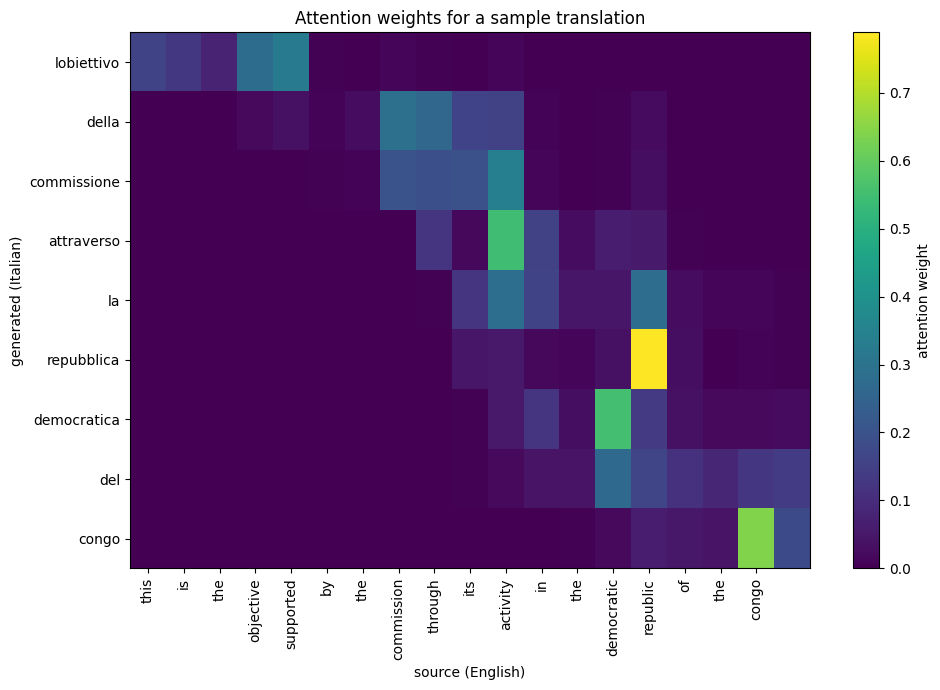

In [ ]:
sample = en_test[27]
words, attn_matrix = translate_att(model_w2v_att, sample, en_vocab, it_vocab, max_len=30)

plt.figure(figsize=(10, 7))
plt.imshow(attn_matrix, aspect='auto', cmap='viridis')
plt.xticks(range(len(sample)), sample, rotation=90)
plt.yticks(range(len(words)), words)
plt.xlabel("source (English)"); plt.ylabel("generated (Italian)")
plt.colorbar(label="attention weight")
plt.title("Attention weights for a sample translation")
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/attention_heatmap.png", dpi=150)
plt.show()

## Task 5 Pivot Translation (Italian to Swedish via English)

In [ ]:
sv_path = f"{DATA_DIR}/europarl-v7.sv-en.sv"
en_sv_path = f"{DATA_DIR}/europarl-v7.sv-en.en"
print(os.path.exists(sv_path), os.path.exists(en_sv_path))

with open(sv_path, encoding='utf-8') as f: sv_lines = f.readlines()
with open(en_sv_path, encoding='utf-8') as f: en2_lines = f.readlines()
print(f"Swedish lines: {len(sv_lines)}, English lines: {len(en2_lines)}")

True True
Swedish lines: 1862234, English lines: 1862234


In [ ]:
# same preprocessing pipeline
pairs = [(e, s) for e, s in zip(en2_lines, sv_lines) if is_valid_pair(e, s)]
en2_lines, sv_lines = zip(*pairs)
print(f"after empty/XML filter: {len(en2_lines)}")

pairs = [(e, s) for e, s in zip(en2_lines, sv_lines)
         if len(e.split()) <= MAX_LEN and len(s.split()) <= MAX_LEN]
en2_lines, sv_lines = zip(*pairs)
print(f"after length filter: {len(en2_lines)}")

random.seed(123)
n = int(len(sv_lines) * 0.1)
idx = random.sample(range(len(sv_lines)), k=n)
en2_sample = [en2_lines[i] for i in idx]
sv_sample  = [sv_lines[i] for i in idx]

en2_sample = preprocess_corpus(en2_sample)
sv_sample  = preprocess_corpus(sv_sample)

pairs = [(e, s) for e, s in zip(en2_sample, sv_sample)
         if len(e) <= MAX_LEN and len(s) <= MAX_LEN]
en2_sample, sv_sample = zip(*pairs)
en2_sample, sv_sample = list(en2_sample), list(sv_sample)
print(f"final pairs: {len(en2_sample)}")

after empty/XML filter: 1848423
after length filter: 1837686
final pairs: 183764


In [ ]:
# split, vocab, embedding, loaders for en-sv
en2_tv, en2_test, sv_tv, sv_test = train_test_split(
    en2_sample, sv_sample, test_size=0.20, random_state=42)
en2_train, en2_val, sv_train, sv_val = train_test_split(
    en2_tv, sv_tv, test_size=0.25, random_state=42)
print(f"train={len(en2_train)} val={len(en2_val)} test={len(en2_test)}")

en2_vocab = build_vocab(en2_train)
sv_vocab  = build_vocab(sv_train)

en2_w2v = word2vec_embedding(en2_train, en2_vocab)

train_loader_sv = create_loader(en2_train, sv_train, en2_vocab, sv_vocab)
val_loader_sv   = create_loader(en2_val,   sv_val,   en2_vocab, sv_vocab)
test_loader_sv  = create_loader(en2_test,  sv_test,  en2_vocab, sv_vocab)

train=110258 val=36753 test=36753
Word2Vec coverage: 12653/30004 vocab words found


In [ ]:
# train en-sv model
model_en_sv, history_en_sv = train_variant_v2("en-sv w2v", en2_w2v,
                                              train_loader_sv, val_loader_sv,
                                              sv_vocab, epochs=50)
torch.save(model_en_sv.state_dict(), f"{DATA_DIR}/en_sv_model.pt")

criterion_sv = torch.nn.CrossEntropyLoss(ignore_index=sv_vocab["[FILL]"])
t_loss, t_acc, t_f1 = evaluate(model_en_sv, test_loader_sv, criterion_sv, sv_vocab)
print(f"[en-sv] Test loss: {t_loss:.4f} | acc: {t_acc:.4f} | macro F1: {t_f1:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

[en-sv w2v] epoch 0: train_loss=6.9586 | val_loss=6.3345 | val_acc=0.0849 | val_f1=0.0001
[en-sv w2v] epoch 10: train_loss=4.3466 | val_loss=4.5019 | val_acc=0.2718 | val_f1=0.0180
[en-sv w2v] epoch 20: train_loss=3.8261 | val_loss=4.3056 | val_acc=0.2875 | val_f1=0.0337
[en-sv w2v] epoch 30: train_loss=3.5483 | val_loss=4.3030 | val_acc=0.2881 | val_f1=0.0397
[en-sv w2v] epoch 40: train_loss=3.3633 | val_loss=4.3567 | val_acc=0.2862 | val_f1=0.0416
[en-sv w2v] epoch 49: train_loss=3.2391 | val_loss=4.4196 | val_acc=0.2828 | val_f1=0.0418
[en-sv] Test loss: 4.4172 | acc: 0.2815 | macro F1: 0.0434


In [ ]:
# translate Italian to Swedish by going through English

def pivot_translate(it_tokens):
    en_text = translate(model_w2v_rev, encode(it_tokens, it_vocab), it_vocab, en_vocab)
    en_tokens = en_text.split()
    if len(en_tokens) == 0:
        return [], []
    sv_text = translate(model_en_sv, encode(en_tokens, en2_vocab), en2_vocab, sv_vocab)
    return en_tokens, sv_text.split()

for i in [0, 7, 111]:
    eng, swe = pivot_translate(it_test[i])
    print("Italian:  ", " ".join(it_test[i]))
    print("  -> EN:  ", " ".join(eng))
    print("  -> SV:  ", " ".join(swe))
    print()

Italian:   se non vogliamo correre il rischio che ci venga rimproverato di aver incoraggiato la produzione di eccedenze a livelli intollerabili per i paesi candidati dobbiamo orientarci ad una politica agricola integrata e guardarci dal trasferire il sistema dei pagamenti diretti
  -> EN:   if we are not to be able to get to grips with the dairy cmo subsidies to be repaid we will be able to use the export of subsidies to the detriment of our farmers to reduce the burden of proof of the euro zone we will not be able to reduce the price of kg per hectare per hectare for the dollar
  -> SV:   om vi kan hoppas att vi kommer att kunna frigöra [UNKNOWN] i [UNKNOWN] [UNKNOWN] [UNKNOWN] [UNKNOWN] [UNKNOWN] [UNKNOWN] [UNKNOWN] [UNKNOWN]

Italian:   le conclusioni sono le seguenti debolezza dei sistemi di controllo degli stati membri e in una certa misura delleffettiva supervisione da parte della commissione la distribuzione degli errori nei pagamenti per settore è piuttosto elevata così come lo

In [ ]:
# check how well the English to Swedish model translates
smooth = SmoothingFunction().method1
refs, hyps = [], []
for i in range(300):
    sv_out = translate(model_en_sv, encode(en2_test[i], en2_vocab), en2_vocab, sv_vocab).split()
    hyps.append(sv_out)
    refs.append([sv_test[i]])
print(f"[en-sv, gold English] BLEU: {corpus_bleu(refs, hyps, smoothing_function=smooth):.4f}")

[en-sv, gold English] BLEU: 0.0248
